Pipeline steps: 
Using Gensim tokenizer + word2vec:
0) convert to lower case, remove emojis, punctuation, special characters and simple preprocessing (using using gensim.simple_preprocess) 
1) indexing (map tokens to indexes) (this is done using keras tokenizer) 
2) make lookup matrix: index -> word2vec vector
3) pad indexed sequences so all are of same length
4) Train LSTM (use word2vec embedding layer), define no. of epochs and other hyperparameters,epochs, plot validation and training set loss per epoch : 
(i) Pass indexed sequences to LSTM, embedding layers convert word to vector using lookup matrix
5) Inference

In [1]:
# Imports
import sklearn
import pandas as pd
import numpy as np

# Data Exploration

In [2]:
dataframe = pd.read_csv('data_labeled.csv')
dataframe.columns = ["sentence", "label"]
print(dataframe.head())
print(dataframe.describe())


                                            sentence  label
0                                              Today      1
1  I want to print the occasion and a photo on th...      1
2  When I will get, how many days it will take to...      1
3                                           Delivery      1
4    I want gift suggestion for general in all gifts      2
             label
count  1084.000000
mean      1.153137
std       1.089944
min      -2.000000
25%       1.000000
50%       1.000000
75%       2.000000
max       2.000000


Label Distribution:
label
-2     49
-1     93
 1    443
 2    499
Name: count, dtype: int64

Total samples: 1084


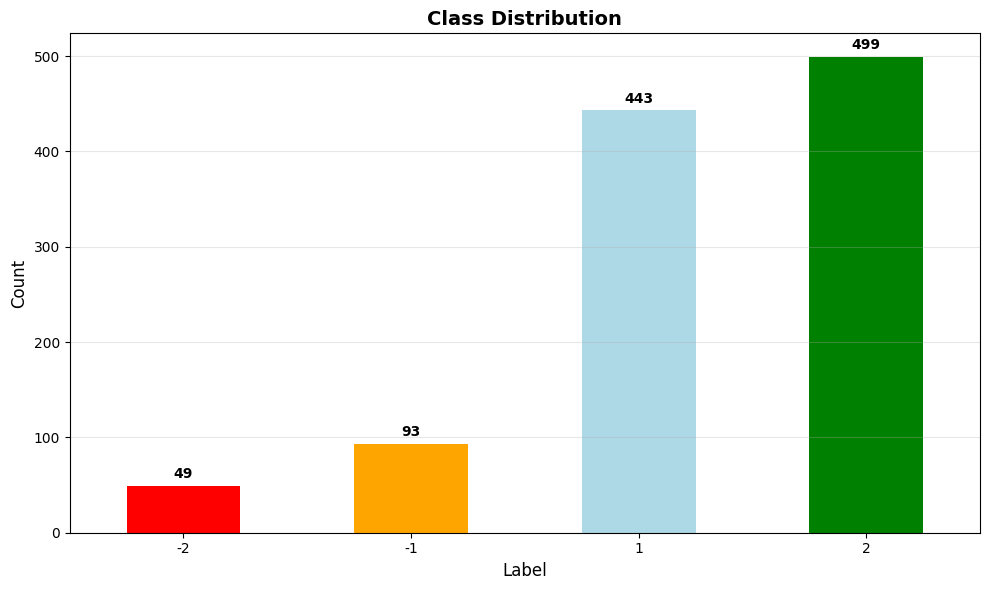


Label Meanings:
-2: Escalate to human agent
-1: Track order/order status (login required)
 1: General conversation/company policy
 2: Product recommendation


In [3]:
import matplotlib.pyplot as plt

# Count label distribution
label_counts = dataframe['label'].value_counts().sort_index()
print("Label Distribution:")
print(label_counts)
print(f"\nTotal samples: {len(dataframe)}")

# Create bar plot
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color=['red', 'orange', 'lightblue', 'green'])
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print label meanings
print("\nLabel Meanings:")
print("-2: Escalate to human agent")
print("-1: Track order/order status (login required)")
print(" 1: General conversation/company policy")
print(" 2: Product recommendation")

# Pipeline

In [4]:
# Step 0: Preprocessing using gensim.simple_preprocess
from gensim.utils import simple_preprocess

def preprocess_text(text):
    """
    Preprocesses text using gensim.simple_preprocess which:
    - Converts to lowercase
    - Removes punctuation
    - Removes special characters
    - Tokenizes into words (min_len=2, max_len=15 by default)
    """
    # simple_preprocess returns a list of tokens
    tokens = simple_preprocess(text, deacc=True)  # deacc=True removes accents
    return tokens

# Apply preprocessing to all sentences
dataframe['preprocessed_tokens'] = dataframe['sentence'].apply(preprocess_text)

# Display some examples
print("Original vs Preprocessed:")
print("-" * 80)
for i in range(5):
    print(f"\nOriginal: {dataframe['sentence'].iloc[i]}")
    print(f"Preprocessed: {dataframe['preprocessed_tokens'].iloc[i]}")
print("-" * 80)
print(f"\nTotal samples preprocessed: {len(dataframe)}")

Original vs Preprocessed:
--------------------------------------------------------------------------------

Original: Today
Preprocessed: ['today']

Original: I want to print the occasion and a photo on the cover page
Preprocessed: ['want', 'to', 'print', 'the', 'occasion', 'and', 'photo', 'on', 'the', 'cover', 'page']

Original: When I will get, how many days it will take to reach me . I live in Banglore
Preprocessed: ['when', 'will', 'get', 'how', 'many', 'days', 'it', 'will', 'take', 'to', 'reach', 'me', 'live', 'in', 'banglore']

Original: Delivery
Preprocessed: ['delivery']

Original: I want gift suggestion for general in all gifts
Preprocessed: ['want', 'gift', 'suggestion', 'for', 'general', 'in', 'all', 'gifts']
--------------------------------------------------------------------------------

Total samples preprocessed: 1084


In [5]:
# Step 1: Indexing using Keras Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer

# Convert list of tokens back to space-separated strings for Keras Tokenizer
dataframe['preprocessed_text'] = dataframe['preprocessed_tokens'].apply(lambda x: ' '.join(x))

# Initialize Keras Tokenizer
# num_words=None means we'll use all unique words
tokenizer = Tokenizer(num_words=None, oov_token='<OOV>')

# Fit the tokenizer on the preprocessed text
tokenizer.fit_on_texts(dataframe['preprocessed_text'])

# Convert texts to sequences of integers (indexes)
sequences = tokenizer.texts_to_sequences(dataframe['preprocessed_text'])
dataframe['indexed_sequence'] = sequences

# Display tokenizer information
print("Tokenizer Statistics:")
print("-" * 80)
print(f"Vocabulary size (unique tokens): {len(tokenizer.word_index)}")
print(f"Total documents: {tokenizer.document_count}")
print(f"\nFirst 20 words in vocabulary (word -> index):")
word_index_items = list(tokenizer.word_index.items())[:20]
for word, idx in word_index_items:
    print(f"  '{word}' -> {idx}")

print("\n" + "-" * 80)
print("Example transformations:")
print("-" * 80)
for i in range(3):
    print(f"\nOriginal: {dataframe['sentence'].iloc[i]}")
    print(f"Tokens: {dataframe['preprocessed_tokens'].iloc[i]}")
    print(f"Indexed: {dataframe['indexed_sequence'].iloc[i]}")
    
print("\n" + "-" * 80)
print(f"Sequence lengths (min, max, mean):")
seq_lengths = [len(seq) for seq in sequences]
print(f"  Min: {min(seq_lengths)}, Max: {max(seq_lengths)}, Mean: {np.mean(seq_lengths):.2f}")

Tokenizer Statistics:
--------------------------------------------------------------------------------
Vocabulary size (unique tokens): 1090
Total documents: 1084

First 20 words in vocabulary (word -> index):
  '<OOV>' -> 1
  'for' -> 2
  'want' -> 3
  'gift' -> 4
  'to' -> 5
  'order' -> 6
  'suggestion' -> 7
  'my' -> 8
  'need' -> 9
  'me' -> 10
  'is' -> 11
  'can' -> 12
  'in' -> 13
  'the' -> 14
  'delivery' -> 15
  'how' -> 16
  'what' -> 17
  'you' -> 18
  'do' -> 19
  'birthday' -> 20

--------------------------------------------------------------------------------
Example transformations:
--------------------------------------------------------------------------------

Original: Today
Tokens: ['today']
Indexed: [104]

Original: I want to print the occasion and a photo on the cover page
Tokens: ['want', 'to', 'print', 'the', 'occasion', 'and', 'photo', 'on', 'the', 'cover', 'page']
Indexed: [3, 5, 282, 14, 452, 50, 63, 24, 14, 146, 453]

Original: When I will get, how many da

/Users/geetansh/Desktop/verve/chatbot/venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [6]:
# Step 2: Load pretrained Word2Vec and build embedding lookup matrix
import gensim.downloader as api

# Load pretrained Word2Vec model (Google News, 300-dimensional vectors, 3M words)
# This is a famous pretrained model widely used in NLP applications
print("Loading pretrained Word2Vec model (Google News - 300d)...")
print("This may take a few minutes on first download...")
word2vec_model = api.load('word2vec-google-news-300')

print(f"\nPretrained Word2Vec model loaded:")
print(f"  Vocabulary size: {len(word2vec_model)} words")
print(f"  Embedding dimension: {word2vec_model.vector_size}")

# Create embedding matrix: index -> word2vec vector
# Matrix shape: (vocab_size + 1, embedding_dim)
# +1 because index 0 is reserved (for padding)
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = word2vec_model.vector_size
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Fill the embedding matrix
words_found = 0
words_not_found = 0
words_not_found_list = []

for word, idx in tokenizer.word_index.items():
    if word in word2vec_model:
        embedding_matrix[idx] = word2vec_model[word]
        words_found += 1
    else:
        # Word not in word2vec vocabulary, leave as zeros or initialize randomly
        words_not_found += 1
        if words_not_found <= 10:  # Store first 10 missing words for display
            words_not_found_list.append(word)

print(f"\nEmbedding Matrix created:")
print(f"  Shape: {embedding_matrix.shape}")
print(f"  Vocabulary size (including padding): {vocab_size}")
print(f"  Embedding dimension: {embedding_dim}")
print(f"  Words found in pretrained Word2Vec: {words_found}")
print(f"  Words not found (initialized to zeros): {words_not_found}")
print(f"  Coverage: {100 * words_found / len(tokenizer.word_index):.2f}%")

if words_not_found_list:
    print(f"\n  First few missing words: {words_not_found_list}")

# Show example: word -> index -> vector
print("\n" + "-" * 80)
print("Example word embeddings (first 3 words found in pretrained model):")
print("-" * 80)
count = 0
for word, idx in tokenizer.word_index.items():
    if word in word2vec_model and count < 3:
        print(f"\nWord: '{word}'")
        print(f"Index: {idx}")
        print(f"Vector (first 10 dims): {embedding_matrix[idx][:10]}")
        print(f"Vector shape: {embedding_matrix[idx].shape}")
        count += 1
    if count >= 3:
        break

Loading pretrained Word2Vec model (Google News - 300d)...
This may take a few minutes on first download...
[==================================================] 100.0% 1662.8/1662.8MB downloaded

Pretrained Word2Vec model loaded:
  Vocabulary size: 3000000 words
  Embedding dimension: 300

Embedding Matrix created:
  Shape: (1091, 300)
  Vocabulary size (including padding): 1091
  Embedding dimension: 300
  Words found in pretrained Word2Vec: 1024
  Words not found (initialized to zeros): 66
  Coverage: 93.94%

  First few missing words: ['<OOV>', 'to', 'of', 'personalised', 'and', 'pincode', 'customise', 'customised', 'giftcart', 'giftkart']

--------------------------------------------------------------------------------
Example word embeddings (first 3 words found in pretrained model):
--------------------------------------------------------------------------------

Word: 'for'
Index: 2
Vector (first 10 dims): [-0.01177979 -0.04736328  0.04467773  0.06347656 -0.01818848 -0.06396484
 

In [7]:
# Step 3: Pad sequences to have uniform length
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Determine max sequence length
max_length = max(seq_lengths)
print(f"Maximum sequence length: {max_length}")

# Pad all sequences to max_length
# padding='post' adds zeros at the end
# truncating='post' truncates from the end if sequence is longer
padded_sequences = pad_sequences(
    sequences, 
    maxlen=max_length, 
    padding='post', 
    truncating='post'
)

print(f"\nPadded sequences shape: {padded_sequences.shape}")
print(f"  Number of samples: {padded_sequences.shape[0]}")
print(f"  Sequence length: {padded_sequences.shape[1]}")

# Show example of padding
print("\n" + "-" * 80)
print("Example of padding:")
print("-" * 80)
for i in range(2):
    print(f"\nOriginal sequence length: {len(sequences[i])}")
    print(f"Original: {sequences[i]}")
    print(f"Padded: {padded_sequences[i]}")
    print(f"Padded length: {len(padded_sequences[i])}")

Maximum sequence length: 33

Padded sequences shape: (1084, 33)
  Number of samples: 1084
  Sequence length: 33

--------------------------------------------------------------------------------
Example of padding:
--------------------------------------------------------------------------------

Original sequence length: 1
Original: [104]
Padded: [104   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
Padded length: 33

Original sequence length: 11
Original: [3, 5, 282, 14, 452, 50, 63, 24, 14, 146, 453]
Padded: [  3   5 282  14 452  50  63  24  14 146 453   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
Padded length: 33


In [9]:
# Step 4: Build and Train LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# Prepare data
X = padded_sequences
y = dataframe['label'].values

# Convert labels to non-negative (LSTM typically expects 0-indexed classes)
# Labels: -2, -1, 1, 2 -> 0, 1, 2, 3
label_mapping = {-2: 0, -1: 1, 1: 2, 2: 3}
y_mapped = np.array([label_mapping[label] for label in y])

print("Label mapping:")
for original, mapped in label_mapping.items():
    print(f"  {original} -> {mapped}")

# Split data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y_mapped, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_mapped
)

print(f"\nData split:")
print(f"  Training samples: {len(X_train)}")
print(f"  Validation samples: {len(X_val)}")

# Build LSTM model
model = Sequential([
    # Embedding layer using pretrained word2vec weights
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False  # Freeze pretrained embeddings
    ),
    
    # LSTM layers
    LSTM(128, return_sequences=True, dropout=0.2),
    LSTM(64, dropout=0.2),
    
    # Dense layers
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')  # 4 classes (0, 1, 2, 3)
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Build the model to initialize all layers and see proper shapes
model.build(input_shape=(None, max_length))

print("\nModel Architecture:")
print("=" * 80)
model.summary()
print("=" * 80)

Label mapping:
  -2 -> 0
  -1 -> 1
  1 -> 2
  2 -> 3

Data split:
  Training samples: 867
  Validation samples: 217

Model Architecture:


/Users/geetansh/Desktop/verve/chatbot/venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 33, 300)        │       327,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 33, 128)        │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 598,568 (2.28 MB)

 Trainable params: 271,268 (1.03 MB)

 Non-trainable params: 327,300 (1.25 MB)

In [10]:
# Train the model
print("Training LSTM model...")
print("=" * 80)

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("\n" + "=" * 80)
print("Training completed!")
print("=" * 80)

Training LSTM model...
Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.4441 - loss: 1.2200 - val_accuracy: 0.5069 - val_loss: 0.9427
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6967 - loss: 0.8389 - val_accuracy: 0.7880 - val_loss: 0.6009
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7785 - loss: 0.6299 - val_accuracy: 0.7465 - val_loss: 0.6094
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8224 - loss: 0.5065 - val_accuracy: 0.8341 - val_loss: 0.4895
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8454 - loss: 0.4694 - val_accuracy: 0.8479 - val_loss: 0.5047
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8604 - loss: 0.4283 - val_accuracy: 0.8341 - val_loss: 0.4356
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8616 - loss: 0.3941 - val_accuracy: 0.8479 - val_loss: 0.3934
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8651 - loss: 0.3902 - v

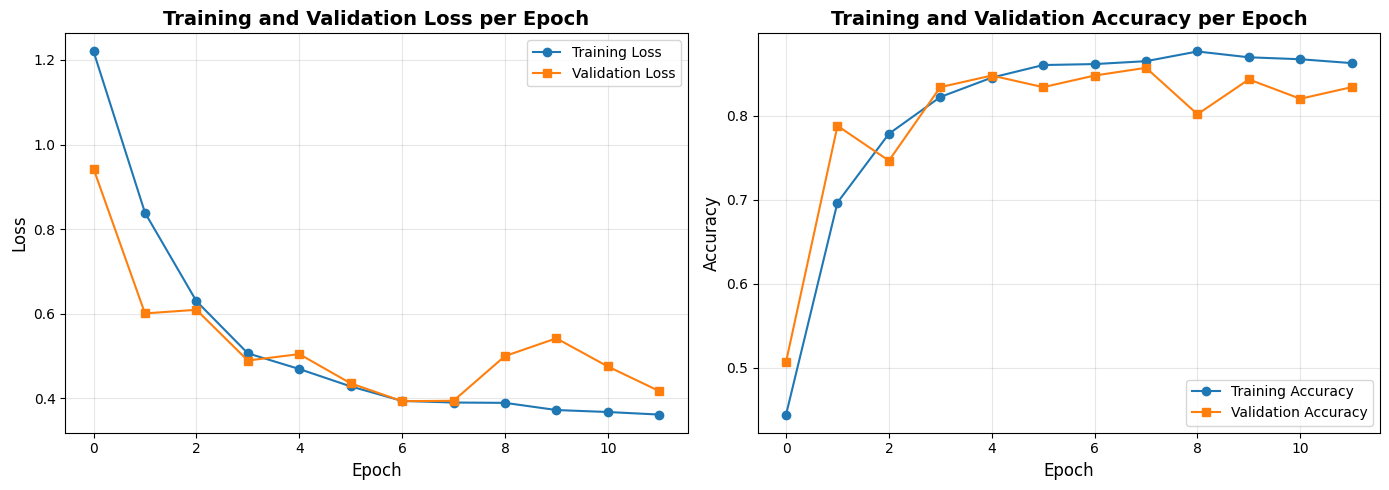


Final Training Metrics:
  Training Loss: 0.3618
  Training Accuracy: 0.8627
  Validation Loss: 0.4172
  Validation Accuracy: 0.8341


In [11]:
# Plot training and validation loss per epoch
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss per Epoch', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training and Validation Accuracy per Epoch', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print("\nFinal Training Metrics:")
print(f"  Training Loss: {history.history['loss'][-1]:.4f}")
print(f"  Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"  Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"  Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

In [12]:
# Step 5: Inference Function
def predict_intent(sentence):
    """
    Predicts the intent/label for a given sentence using the trained LSTM model.
    
    Args:
        sentence (str): Input sentence to classify
    
    Returns:
        dict: Contains predicted label, confidence, and probabilities for all classes
    """
    # Step 1: Preprocess the sentence (same as training)
    tokens = preprocess_text(sentence)
    preprocessed_text = ' '.join(tokens)
    
    # Step 2: Convert to sequence of indices
    sequence = tokenizer.texts_to_sequences([preprocessed_text])
    
    # Step 3: Pad the sequence
    padded = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')
    
    # Step 4: Make prediction
    prediction = model.predict(padded, verbose=0)
    predicted_class = np.argmax(prediction[0])
    confidence = prediction[0][predicted_class]
    
    # Step 5: Map back to original label
    reverse_label_mapping = {0: -2, 1: -1, 2: 1, 3: 2}
    original_label = reverse_label_mapping[predicted_class]
    
    # Label descriptions
    label_descriptions = {
        -2: "Escalate to human agent",
        -1: "Track order/order status (login required)",
        1: "General conversation/company policy",
        2: "Product recommendation"
    }
    
    return {
        'sentence': sentence,
        'preprocessed': tokens,
        'label': original_label,
        'description': label_descriptions[original_label],
        'confidence': float(confidence),
        'all_probabilities': {
            '-2 (Escalate)': float(prediction[0][0]),
            '-1 (Track order)': float(prediction[0][1]),
            '1 (Conversation)': float(prediction[0][2]),
            '2 (Recommendation)': float(prediction[0][3])
        }
    }

print("Inference function ready!")
print("\nUsage: predict_intent('your sentence here')")

# Test the inference function with example sentences
test_sentences = [
    "I want to buy a laptop",
    "Where is my order?",
    "What is your return policy?",
    "This is unacceptable, I need to speak to a manager",
    "Hi, how are you?",
    "Can you recommend a good phone?"
]

print("Testing Inference Function:")
print("=" * 80)

for sentence in test_sentences:
    result = predict_intent(sentence)
    print(f"\nSentence: {result['sentence']}")
    print(f"Predicted Label: {result['label']} - {result['description']}")
    print(f"Confidence: {result['confidence']:.2%}")
    print(f"Probabilities:")
    for label, prob in result['all_probabilities'].items():
        print(f"  {label}: {prob:.4f}")
    print("-" * 80)

Inference function ready!

Usage: predict_intent('your sentence here')
Testing Inference Function:

Sentence: I want to buy a laptop
Predicted Label: 2 - Product recommendation
Confidence: 99.62%
Probabilities:
  -2 (Escalate): 0.0003
  -1 (Track order): 0.0008
  1 (Conversation): 0.0027
  2 (Recommendation): 0.9962
--------------------------------------------------------------------------------

Sentence: Where is my order?
Predicted Label: -1 - Track order/order status (login required)
Confidence: 45.84%
Probabilities:
  -2 (Escalate): 0.3197
  -1 (Track order): 0.4584
  1 (Conversation): 0.1514
  2 (Recommendation): 0.0705
--------------------------------------------------------------------------------

Sentence: What is your return policy?
Predicted Label: 1 - General conversation/company policy
Confidence: 97.03%
Probabilities:
  -2 (Escalate): 0.0035
  -1 (Track order): 0.0131
  1 (Conversation): 0.9703
  2 (Recommendation): 0.0132
------------------------------------------------

In [13]:
while True:
    user_input = input("\nEnter a sentence to classify (or 'exit' to quit): ")
    if user_input.lower() == 'exit':
        print("Exiting inference loop.")
        break
    prediction = predict_intent(user_input)
    print(f"\nPredicted Label: {prediction['label']} - {prediction['description']}")
    print(f"Confidence: {prediction['confidence']:.2%}")
    print("Probabilities:")
    for label, prob in prediction['all_probabilities'].items():
        print(f"  {label}: {prob:.4f}")


Predicted Label: 2 - Product recommendation
Confidence: 99.78%
Probabilities:
  -2 (Escalate): 0.0002
  -1 (Track order): 0.0005
  1 (Conversation): 0.0016
  2 (Recommendation): 0.9978

Predicted Label: 2 - Product recommendation
Confidence: 99.80%
Probabilities:
  -2 (Escalate): 0.0001
  -1 (Track order): 0.0004
  1 (Conversation): 0.0015
  2 (Recommendation): 0.9980

Predicted Label: 2 - Product recommendation
Confidence: 98.76%
Probabilities:
  -2 (Escalate): 0.0012
  -1 (Track order): 0.0031
  1 (Conversation): 0.0081
  2 (Recommendation): 0.9876

Predicted Label: 2 - Product recommendation
Confidence: 99.60%
Probabilities:
  -2 (Escalate): 0.0003
  -1 (Track order): 0.0009
  1 (Conversation): 0.0028
  2 (Recommendation): 0.9960

Predicted Label: 2 - Product recommendation
Confidence: 99.63%
Probabilities:
  -2 (Escalate): 0.0003
  -1 (Track order): 0.0008
  1 (Conversation): 0.0026
  2 (Recommendation): 0.9963

Predicted Label: 1 - General conversation/company policy
Confidence: 

# Save Model and Artifacts

In [14]:
# Save the trained model weights and necessary artifacts
import pickle

# Save the model weights
model.save('lstm_intent_classifier.keras')
print("✓ Model saved as 'lstm_intent_classifier.keras'")

# Save the tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("✓ Tokenizer saved as 'tokenizer.pkl'")

# Save important parameters
model_config = {
    'max_length': max_length,
    'vocab_size': vocab_size,
    'embedding_dim': embedding_dim,
    'label_mapping': label_mapping
}

with open('model_config.pkl', 'wb') as f:
    pickle.dump(model_config, f)
print("✓ Model configuration saved as 'model_config.pkl'")

print("\n" + "=" * 80)
print("All artifacts saved successfully!")
print("=" * 80)

✓ Model saved as 'lstm_intent_classifier.keras'
✓ Tokenizer saved as 'tokenizer.pkl'
✓ Model configuration saved as 'model_config.pkl'

All artifacts saved successfully!


# Load Model and Run Inference (Fresh Start)

In [16]:
# FRESH START: Load model and run inference
# This code can be run in a fresh Python session/notebook

import numpy as np
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.utils import simple_preprocess

print("Loading saved model and artifacts...")
print("=" * 80)

# Load the trained model
loaded_model = load_model('lstm_intent_classifier.keras')
print("✓ Model loaded from 'lstm_intent_classifier.keras'")

# Load the tokenizer
with open('tokenizer.pkl', 'rb') as f:
    loaded_tokenizer = pickle.load(f)
print("✓ Tokenizer loaded from 'tokenizer.pkl'")

# Load model configuration
with open('model_config.pkl', 'rb') as f:
    loaded_config = pickle.load(f)
print("✓ Configuration loaded from 'model_config.pkl'")

print("\nModel Configuration:")
print(f"  Max sequence length: {loaded_config['max_length']}")
print(f"  Vocabulary size: {loaded_config['vocab_size']}")
print(f"  Embedding dimension: {loaded_config['embedding_dim']}")
print("=" * 80)

Loading saved model and artifacts...
✓ Model loaded from 'lstm_intent_classifier.keras'
✓ Tokenizer loaded from 'tokenizer.pkl'
✓ Configuration loaded from 'model_config.pkl'

Model Configuration:
  Max sequence length: 33
  Vocabulary size: 1091
  Embedding dimension: 300


In [17]:
# Define inference function using loaded artifacts
def predict_intent_from_loaded_model(sentence):
    """
    Predicts intent using the loaded model.
    
    Args:
        sentence (str): Input sentence to classify
    
    Returns:
        dict: Contains predicted label, confidence, and probabilities
    """
    # Preprocessing function (same as training)
    def preprocess_text(text):
        tokens = simple_preprocess(text, deacc=True)
        return tokens
    
    # Preprocess the sentence
    tokens = preprocess_text(sentence)
    preprocessed_text = ' '.join(tokens)
    
    # Convert to sequence of indices
    sequence = loaded_tokenizer.texts_to_sequences([preprocessed_text])
    
    # Pad the sequence
    padded = pad_sequences(
        sequence, 
        maxlen=loaded_config['max_length'], 
        padding='post', 
        truncating='post'
    )
    
    # Make prediction
    prediction = loaded_model.predict(padded, verbose=0)
    predicted_class = np.argmax(prediction[0])
    confidence = prediction[0][predicted_class]
    
    # Map back to original label
    reverse_label_mapping = {0: -2, 1: -1, 2: 1, 3: 2}
    original_label = reverse_label_mapping[predicted_class]
    
    # Label descriptions
    label_descriptions = {
        -2: "Escalate to human agent",
        -1: "Track order/order status (login required)",
        1: "General conversation/company policy",
        2: "Product recommendation"
    }
    
    return {
        'sentence': sentence,
        'preprocessed': tokens,
        'label': original_label,
        'description': label_descriptions[original_label],
        'confidence': float(confidence),
        'all_probabilities': {
            '-2 (Escalate)': float(prediction[0][0]),
            '-1 (Track order)': float(prediction[0][1]),
            '1 (Conversation)': float(prediction[0][2]),
            '2 (Recommendation)': float(prediction[0][3])
        }
    }

print("✓ Inference function ready!")
print("\nUsage: predict_intent_from_loaded_model('your sentence here')")

✓ Inference function ready!

Usage: predict_intent_from_loaded_model('your sentence here')


In [19]:
# Test inference with loaded model
test_sentences = [
    "I want to buy a laptop",
    "Where is my order?",
    "What is your return policy?",
    "This is unacceptable, I need to speak to a manager",
    "Hi, how are you?",
    "Can you recommend a good phone?"
]

print("Testing Loaded Model:")
print("=" * 80)

for sentence in test_sentences:
    result = predict_intent_from_loaded_model(sentence)
    print(f"\nSentence: {result['sentence']}")
    print(f"Predicted Label: {result['label']} - {result['description']}")
    print(f"Confidence: {result['confidence']:.2%}")
    print(f"Top Probabilities:")
    # Sort by probability descending
    sorted_probs = sorted(result['all_probabilities'].items(), key=lambda x: x[1], reverse=True)
    for label, prob in sorted_probs:
        print(f"  {label}: {prob:.4f}")
    print("-" * 80)

Testing Loaded Model:

Sentence: I want to buy a laptop
Predicted Label: 2 - Product recommendation
Confidence: 99.62%
Top Probabilities:
  2 (Recommendation): 0.9962
  1 (Conversation): 0.0027
  -1 (Track order): 0.0008
  -2 (Escalate): 0.0003
--------------------------------------------------------------------------------

Sentence: Where is my order?
Predicted Label: -1 - Track order/order status (login required)
Confidence: 45.84%
Top Probabilities:
  -1 (Track order): 0.4584
  -2 (Escalate): 0.3197
  1 (Conversation): 0.1514
  2 (Recommendation): 0.0705
--------------------------------------------------------------------------------

Sentence: What is your return policy?
Predicted Label: 1 - General conversation/company policy
Confidence: 97.03%
Top Probabilities:
  1 (Conversation): 0.9703
  2 (Recommendation): 0.0132
  -1 (Track order): 0.0131
  -2 (Escalate): 0.0035
--------------------------------------------------------------------------------

Sentence: This is unacceptable,